# Prueba: Aprendizaje No Supervisado



## Instrucciones

Esta prueba evalúa tu comprensión del aprendizaje no supervisado mediante la aplicación práctica de algoritmos de clustering sobre un dataset real de canciones de Spotify.

- Trabaja de forma **individual**.
- Entrega este notebook **completamente ejecutado** (todas las celdas con output visible).
- Justifica **todas** tus decisiones técnicas. No basta con obtener un resultado: explica por qué has tomado cada decisión.
- Las **celdas de texto** (Markdown) son tan importantes como el código. Serán evaluadas con el mismo peso.
- Está permitido consultar, **exclusivamente**, la documentación que se puede descargar desde la plataforma Moodle.

---

## Dataset

Se proporciona el archivo **`spotify_prueba.csv`**, que contiene información sobre canciones de Spotify.

El objetivo del análisis es **segmentar las canciones** en grupos con características musicales similares.

---
## Parte 1 · Carga y exploración de los datos

Realiza un análisis exploratorio inicial que incluya:
•	Visualización de las primeras filas y comprobación de tipos, valores….
•	Estadísticas descriptivas de las variables numéricas.
•	Representación gráfica de las distribuciones más relevantes.
•	Identificación y descarte justificado de las variables que no aporten información para el clustering.


In [14]:
# Carga de librerías y del dataset
import pandas as pd


In [15]:
df_spotify = pd.read_csv("spotify_prueba.csv")
df_spotify.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,customer_id,session_date,region_code
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,381418,2020-01-01 00:00,EU
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,788322,2020-01-01 00:01,EU
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,371463,2020-01-01 00:02,APAC
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,889038,2020-01-01 00:03,US
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,795405,2020-01-01 00:04,LATAM


In [30]:
df_spotify.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4379 entries, 0 to 5096
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   popularity        4379 non-null   int64  
 1   duration_ms       4379 non-null   int64  
 2   explicit          4379 non-null   bool   
 3   danceability      4379 non-null   float64
 4   energy            4379 non-null   float64
 5   key               4379 non-null   int64  
 6   loudness          4379 non-null   float64
 7   mode              4379 non-null   int64  
 8   speechiness       4379 non-null   float64
 9   acousticness      4379 non-null   float64
 10  instrumentalness  4379 non-null   float64
 11  liveness          4379 non-null   float64
 12  valence           4379 non-null   float64
 13  tempo             4379 non-null   float64
 14  time_signature    4379 non-null   int64  
 15  track_genre       4379 non-null   object 
 16  region_code       4379 non-null   object 
dtype

In [34]:
df_spotify_final = df_spotify[["energy","danceability", "loudness","instrumentalness","tempo"]]

In [36]:
df_spotify_final.head()

,energy,danceability,loudness,instrumentalness,tempo
0,0.4610,0.676,-6.746,0.000001,87.917
1,0.1660,0.420,-17.235,0.000006,77.489
2,0.3590,0.438,-9.734,0.000000,76.332
3,0.0596,0.266,-18.515,0.000071,181.740
4,0.4430,0.618,-9.681,0.000000,119.949


In [29]:
print('Filas y columnas:', df_spotify.shape)

Filas y columnas: (4379, 17)


In [32]:
len(df_spotify["instrumentalness"].unique())

1680

In [28]:
df_spotify = df_spotify.dropna()

In [20]:
df_spotify.drop(columns=["track_id","artists","album_name","track_name","session_date","customer_id"], inplace=True)

KeyError: "['track_id', 'artists', 'album_name', 'track_name', 'session_date', 'customer_id'] not found in axis"

**Responde aquí:**

¿Qué variables has descartado y por qué? ¿Qué variables usarás para el clustering?


*Tu respuesta:*He descartado de primeras variables que seguramente sean de valor único y que no aporten valor a la clasificacion como el track_id, el nombre del album, customer_id y del track, los artistas porque me crearían muchas columnas y al ser 1510 diferentes no siento que me aporten tanta info, parecido con session_date y voy a elegir variables como energy, instrumentalness por ejemplo que me permitan ver el agrupar los diferentes tipos de canciones

---
## Parte 2 · Preprocesamiento

Efectúa las tareas que ayudan al preprocesamiento de los datos justificando su necesidad.

In [38]:
# Tu Código
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(df_spotify_final) #Necesito escalar para que kmeans no explote por un posible alto rango


In [42]:
df_spotify_final.head()

,energy,danceability,loudness,instrumentalness,tempo
0,0.4610,0.676,-6.746,0.000001,87.917
1,0.1660,0.420,-17.235,0.000006,77.489
2,0.3590,0.438,-9.734,0.000000,76.332
3,0.0596,0.266,-18.515,0.000071,181.740
4,0.4430,0.618,-9.681,0.000000,119.949


**Responde aquí:**


---
## Parte 3 · Algoritmo K-Means

Aplica el Método del Codo para determinar el valor óptimo de K. Entrena K-Means y visualiza los clusters.

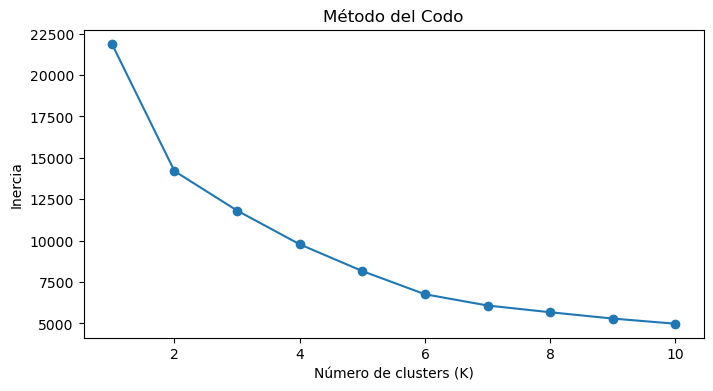

In [39]:
# Tu Código
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled) # X_scaled es el dataset normalizado
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1, 11), inercia, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.show()

In [45]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

labels = kmeans.labels_
centroides = kmeans.cluster_centers_

# -----------------------------
# 4. Mostrar centroides
# -----------------------------
print(" Coordenadas de los centroides:\n")
for i, c in enumerate(centroides):
    print(f"Centroide {i}: energy={c[0]:.2f}, danceability={c[1]:.2f}, loudness={c[2]:.2f}, instrumental={c[3]:.2f}, tempo={c[4]:.2f}")

 Coordenadas de los centroides:

Centroide 0: energy=0.29, danceability=0.22, loudness=0.33, instrumental=-0.33, tempo=0.07
Centroide 1: energy=-1.43, danceability=-1.08, loudness=-1.64, instrumental=1.66, tempo=-0.37


In [43]:
df_spotify_final.head()

,energy,danceability,loudness,instrumentalness,tempo
0,0.4610,0.676,-6.746,0.000001,87.917
1,0.1660,0.420,-17.235,0.000006,77.489
2,0.3590,0.438,-9.734,0.000000,76.332
3,0.0596,0.266,-18.515,0.000071,181.740
4,0.4430,0.618,-9.681,0.000000,119.949


**Responde aquí:**

Describe cada cluster en términos musicales. ¿Qué tipo de canción representa cada grupo? ¿Qué nombre le pondrías?


*Tu respuesta:El primer cluster representa canciones con cierta energia, tempo, ruido y bailables con poca instrumental, podria ser musica pop o canciones para estar tranquilo a lo largo por ejemplo, debido a que las caracteristicas no son muy altas, y el segundo poca energia, poco bailables y ruidosas con mucha instrumental y tempo bajo podrían ser canciones o temas relajantes o romanticos.


## PArte 4 · Algoritmo DBSCAN
Utiliza el gráfico de distancias al vecino más cercano (k-distance graph) para estimar ε. Justifica el valor de min_samples. Visualiza los clusters identificando los puntos de ruido e interpreta su relación con los outliers detectados en el preprocesamiento.

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

In [132]:
min_samples = 6

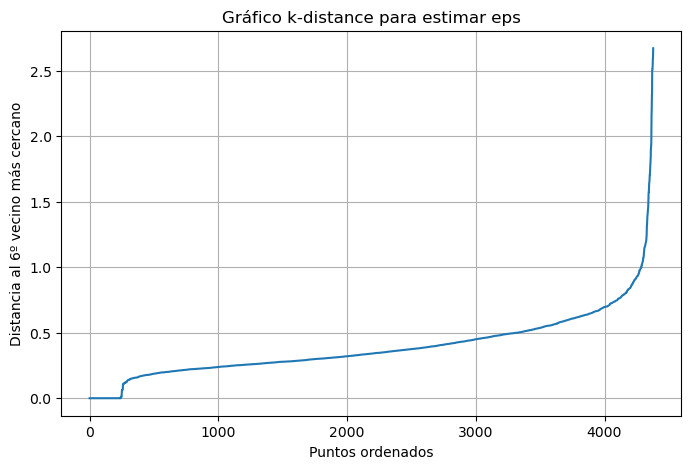

In [133]:
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

# Distancia al k-ésimo vecino más cercano
k_distances = distances[:, min_samples - 1]

# Ordenamos las distancias
k_distances_sorted = np.sort(k_distances)

plt.figure(figsize=(8, 5))
plt.plot(k_distances_sorted)
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {min_samples}º vecino más cercano")
plt.title("Gráfico k-distance para estimar eps")
plt.grid(True)
plt.show()

In [136]:
eps = 0.7
print("Valor elegido para eps:", eps)

Valor elegido para eps: 0.7


In [137]:
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
clusters = dbscan.fit_predict(X_scaled)

df_spotify_final["cluster_dbscan"] = clusters

df_spotify_final["cluster_dbscan"].value_counts().sort_index()

/tmp/ipykernel_27187/2455642934.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_spotify_final["cluster_dbscan"] = clusters


cluster_dbscan
-1     188
 0    4183
 1       8
Name: count, dtype: int64

**Responde aquí:**

*Tu respuesta:* He aplicado la regla de justificacion de numero de dimensiones + 1

He elegido epsilon con 0.7 ya que era el que me daba los clusteres mas coherentes en base a los diferentes valores probados anteriormente

---
## Parte 5 · Comparación entre K-Means y DBSCAN

Esta sección es la más importante de la prueba. Se evalúa tu capacidad para razonar sobre los algoritmos, no solo para aplicarlos.

**Pregunta 5.1**  
¿Los dos algoritmos han producido segmentaciones similares o diferentes? Compara los resultados visualmente.

*Tu respuesta: Los 2 han realizado segmentaciones en 2 clusteres, no podemos saber en que datos se basan cada 1 principalmente porque a priori no tengo forma de representarlos, pero siento que aunque sean similares en numero de clusteres las segmentaciones han sido muy diferentes debido a que el cluster de outliers de DBSCAN era bastante grande

**Pregunta 5.2**  
¿Cuál de los dos algoritmos consideras más adecuado para segmentar canciones? Justifica tu respuesta.

*Tu respuesta:Siento que en este caso DBSCAN es el mas indicado debido a que los generos normalmente suelen tener caracteristicas muy parecidas, por lo que es normal que haya agrupaciones de gran densidad a la hora de distinguir un genero y eso haga que la clasificación de clusters sea más óptima si somos capaces de poner los valores adecuados

**Pregunta 5.3**  
Los outliers del dataset, ¿cómo los ha tratado cada algoritmo? ¿Cuál de los dos comportamientos es más deseable en este caso?

*Tu respuesta:El algoritmo DBSCAN los manda a un clusters diferente que los clasifica como ruido, en cambio k-means los incluye, y en vista del gran numero de ruido que tenemos es preferible usar DBSCAN para que tanto ruido no desajuste nuestro modelo.

**Pregunta 5.4**  
¿Cuál de los dos algoritmos es más sensible a la elección de sus hiperparámetros? ¿Por qué?

*Tu respuesta:Siento que el algoritmo mas sensible es DBSCAN ya que la elección del numero minimo de ejemplo condiciona la densidad necesaria para considerar las agrupaciones, y el epsilon que le metas condiciona la distancia máxima que puede haber entre 2 puntos, haciendo que los minimos cambios sean notables.

---
## Parte 6 · Cuestiones

**Pregunta 6.1**  
¿Cómo sabes si el clustering ha funcionado bien sin disponer de etiquetas reales? ¿Qué métricas o criterios usarías?

*Tu respuesta: Dependiendo del algoritmo tenemos diferentes herramientas como el metodo del codo o el dendrograma por ejemplo que nos ayudan, también depende mucho del tipo de problema, pero trataría de ver y dar una coherencia los clusters en base a los valores promedio y la posible interpretación que le podamos dar, en este caso, siento que para kmeans el metodo del codo nos ayuda, y el DBSCAN el numero de clusters que nos vaya dando el resultado en base al ajuste de los parametros.

**Pregunta 6.2**  
Este dataset tiene variables como `track_genre`. ¿Cambiaría esto el tipo de problema? ¿Usarías el mismo enfoque o uno diferente?

*Tu respuesta:Cambiaría bastante el enfoque, ya que ahora mismo estamos tratando de adivinar el genero en base a sus carácteristicas, pero en cambio si ya lo tenemos, lo que podriamos tratar de ver es que tipo de características o cualidades definen al genero para saber como construir una canción de cierto tipo, haciendo que el problema y enfoque sean distintos